In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from support_assistant.data import load_intents, load_tickets, normalise_text

ROOT = Path.cwd().parents[2]
RAW = ROOT / "data" / "raw"
FIGURES = ROOT / "docs" / "figures"
pd.set_option("display.max_colwidth", 120)

train = load_intents(RAW / "banking77_train.csv")
test = load_intents(RAW / "banking77_test.csv")
print(train.shape, test.shape)
train.head()

(10003, 2) (3080, 2)


,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived after 2 weeks?,card_arrival
2,I have been waiting over a week. Is the card still coming?,card_arrival
3,Can I track my card while it is in the process of delivery?,card_arrival
4,"How do I know if I will get my card, or if it is lost?",card_arrival


In [8]:
print(train["category"].head(200).nunique(),"intents in the first 200 rows")
print(train["category"].nunique(), "intents in the whole file")
train.sample(5, random_state=0)


2 intents in the first 200 rows
77 intents in the whole file


,text,category
7145,How can I transfer money to a beneficiary?,beneficiary_not_allowed
834,How is my ATM deposit not available yet?,pending_cash_withdrawal
3585,There is a vendor name I don't recognize on a payment from my account. I don't think I made this payment.,card_payment_not_recognised
4497,My statement shows charges for things I never purchased. Were my account details stolen?,compromised_card
7046,"Hi, I am interested buying crypto currency but unable to purchase it through the application. I do want to do the ex...",beneficiary_not_allowed


In [13]:
counts = train["category"].value_counts()
print(counts.head(5))

category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
Name: count, dtype: int64


In [14]:
print(counts.tail(5))

category
lost_or_stolen_card         82
card_swallowed              61
card_acceptance             59
virtual_card_not_working    41
contactless_not_working     35
Name: count, dtype: int64


In [15]:
print("intents:", len(counts), "| largest:", counts.max(), "| smallest:", counts.min(), "| mean:", round(counts.mean(), 1))


intents: 77 | largest: 187 | smallest: 35 | mean: 129.9


In [16]:
print("imbalance ratio:", round(counts.max() / counts.min(), 1))


imbalance ratio: 5.3


In [17]:
print("majority-class accuracy:", round(counts.max() / len(train), 4))


majority-class accuracy: 0.0187


In [18]:
print("test examples per intent:", sorted(test["category"].value_counts().unique().tolist()))


test examples per intent: [40]


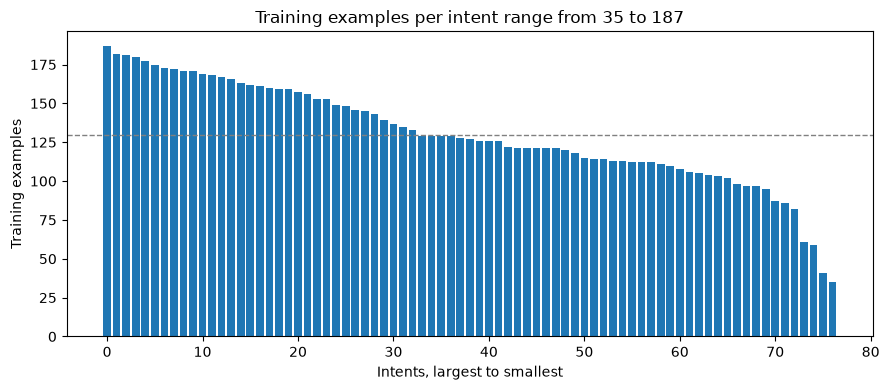

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(counts)), counts.values)
ax.axhline(counts.mean(), linestyle="--", linewidth=1, color="grey")
ax.set_title(f"Training examples per intent range from {counts.min()} to {counts.max()}")
ax.set_xlabel("Intents, largest to smallest")
ax.set_ylabel("Training examples")
fig.tight_layout()
fig.savefig(FIGURES / "b77_class_balance.png", dpi=150)
plt.show()

In [20]:
len(counts)

77

In [21]:
counts.values

array([187, 182, 181, 180, 177, 175, 173, 172, 171, 171, 169, 168, 167,
       166, 163, 162, 161, 160, 159, 159, 157, 156, 153, 153, 149, 148,
       146, 145, 143, 139, 137, 135, 133, 129, 129, 129, 129, 128, 127,
       126, 126, 126, 122, 121, 121, 121, 121, 121, 120, 118, 115, 114,
       114, 113, 113, 112, 112, 112, 111, 110, 108, 106, 105, 104, 103,
       102,  98,  97,  97,  95,  87,  86,  82,  61,  59,  41,  35])

In [22]:
train["chars"] = train["text"].str.len()

In [23]:
train["words"] = train["text"].str.split().str.len()

In [24]:
print(train[["chars", "words"]].describe().round(1))


         chars    words
count  10003.0  10003.0
mean      59.5     11.9
std       40.9      7.9
min       13.0      2.0
25%       36.0      7.0
50%       47.0     10.0
75%       64.0     13.0
max      433.0     79.0


In [25]:
print("words at the 50th, 90th and 99th percentile:", train["words"].quantile([0.5, 0.9, 0.99]).tolist())


words at the 50th, 90th and 99th percentile: [10.0, 22.0, 43.0]


In [28]:
train["text"]

0                                      I am still waiting on my card?
1        What can I do if my card still hasn't arrived after 2 weeks?
2          I have been waiting over a week. Is the card still coming?
3         Can I track my card while it is in the process of delivery?
4              How do I know if I will get my card, or if it is lost?
                                     ...                             
9998                           You provide support in what countries?
9999                               What countries are you supporting?
10000                             What countries are getting support?
10001                                  Are cards available in the EU?
10002                                Which countries are represented?
Name: text, Length: 10003, dtype: str

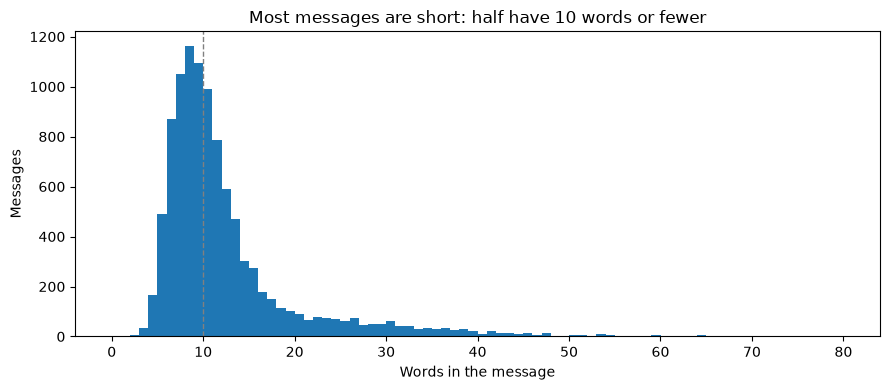

                               text                 category  words
5561             Transfer declined.        declined_transfer      2
5176           pending transaction?     pending_card_payment      2
9979            Supported countries          country_support      2
4847             passcode retrieval       passcode_forgotten      2
4889                  Lost password       passcode_forgotten      2
2187             Cancel Transaction          cancel_transfer      2
4003                  The card PIN?        get_physical_card      3
833   Explain pending transactions.  pending_cash_withdrawal      3
                                                                                                                         text  \
3934  Hearing about your verification results from us may take anywhere from 10 minutes to approximately one hour.  If thi...   
7310  Hi! I'm a university student studying abroad and I noticed that when I was trying to cross-reference my budget for t...   
3

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(train["words"], bins=range(0, train["words"].max() + 2))
ax.axvline(train["words"].median(), linestyle="--", linewidth=1, color="grey")
ax.set_title(f"Most messages are short: half have {int(train['words'].median())} words or fewer")
ax.set_xlabel("Words in the message")
ax.set_ylabel("Messages")
fig.tight_layout()
fig.savefig(FIGURES / "b77_length.png", dpi=150)
plt.show()

by_length = train.sort_values("words")[["text", "category", "words"]]


In [29]:
print(by_length.head(8))
print(by_length.tail(3))

                               text                 category  words
5561             Transfer declined.        declined_transfer      2
5176           pending transaction?     pending_card_payment      2
9979            Supported countries          country_support      2
4847             passcode retrieval       passcode_forgotten      2
4889                  Lost password       passcode_forgotten      2
2187             Cancel Transaction          cancel_transfer      2
4003                  The card PIN?        get_physical_card      3
833   Explain pending transactions.  pending_cash_withdrawal      3
                                                                                                                         text  \
3934  Hearing about your verification results from us may take anywhere from 10 minutes to approximately one hour.  If thi...   
7310  Hi! I'm a university student studying abroad and I noticed that when I was trying to cross-reference my budget for t...   
3

In [30]:
by_class = train.groupby("category")["words"].mean().round(1).sort_values()
print(by_class.head(3))
print(by_class.tail(3))

category
card_acceptance       7.5
top_up_limits         7.7
passcode_forgotten    7.7
Name: words, dtype: float64
category
pending_cash_withdrawal               16.5
transfer_fee_charged                  17.4
transfer_not_received_by_recipient    17.5
Name: words, dtype: float64


In [31]:
print("leading or trailing whitespace:", (train["text"] != train["text"].str.strip()).sum())
print("contain a line break:", train["text"].str.contains("\n").sum())
print("written entirely in capitals:", train["text"].str.isupper().sum())
print("contain a non-ASCII character:", (~train["text"].map(str.isascii)).sum())
train[train["text"].str.isupper()][["text", "category"]]

leading or trailing whitespace: 9
contain a line break: 10
written entirely in capitals: 10
contain a non-ASCII character: 52


,text,category
93,WHAT IS THE SOLUTION OF THIS PROBLEM,card_arrival
1263,HOW LONG THE CARD VALIDITY,card_not_working
1272,WHAT IS THE REASON FOR THAT,card_not_working
1311,WHAT IS THE MAIN REASON OF THIS PROBLEM,card_not_working
1353,HOW LONG TO TAKE THE TIME TO SOLVE,card_not_working
3107,WHAT IS THE ATMOSPHERE OF IT,card_acceptance
7569,HOW DO I TRANSFER MONEY FROM MY BANK ACCOUNT?,transfer_into_account
7801,I CAN NOT FIND THE TOP-UP VERIFICATION CODE.,verify_top_up
8840,I AM MISSING CASH FROM MY BANK ACCOUNT ACCORDING TO MY APP,cash_withdrawal_not_recognised
9360,WHY IS THERE AN EXTRA FEE FOR USING THE ATM??!!!,cash_withdrawal_charge


In [32]:
train["key"] = train["text"].map(normalise_text)
test["key"] = test["text"].map(normalise_text)

print("duplicate messages within train:", train["key"].duplicated().sum())
labels_per_text = train.groupby("key")["category"].nunique()
print("messages carrying more than one label:", (labels_per_text > 1).sum())
print("test messages that also appear in train:", test["key"].isin(set(train["key"])).sum(), "of", len(test))

conflicts = labels_per_text[labels_per_text > 1].index
train[train["key"].isin(conflicts)].sort_values("key")[["text", "category"]].head(10)

duplicate messages within train: 4
messages carrying more than one label: 0
test messages that also appear in train: 7 of 3080


,text,category


In [33]:
synth = load_tickets(RAW / "tickets_5000.csv")
print(synth["subject"].nunique(), "distinct subjects in 5,000 synthetic tickets")
print(synth.groupby("subject")["category"].nunique().max(), "category per subject, at most")
print(pd.crosstab(synth["category"], synth["priority"], normalize="index").round(2)[["low", "medium", "high"]])

print(train["key"].nunique(), "distinct messages in", len(train), "BANKING77 training rows")

20 distinct subjects in 5,000 synthetic tickets
1 category per subject, at most
priority          low  medium  high
category                           
billing          0.29    0.53  0.18
bug              0.19    0.39  0.42
feature_request  0.70    0.30  0.00
login            0.19    0.42  0.39
shipping         0.38    0.51  0.11
9999 distinct messages in 10003 BANKING77 training rows
